In [16]:
# imports
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Leitura do dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()

# Separação da coluna target 
y = students_df["Target"]
students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)

# Normalização dos dados com técnica Min-max
scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(students_df), columns = students_df.columns)

In [23]:
# K-MEANS
# função para plotagem de k-means para qualquer k 
def plotar_kmeans(k):
    # Algoritmo k-means
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    clusters = kmeans.fit_predict(scaled_students_df)

    # Método PCA para visualização gráfica 3D
    pca = PCA(n_components = 3)
    principalComponents = pca.fit_transform(scaled_students_df)
    pca_df = pd.DataFrame(
        data = principalComponents,
        columns = ['principal component 1', 'principal component 2', 'principal component 3'])

    graphic_kmeans_df = pca_df.copy()
    graphic_kmeans_df['Agrupamentos'] = clusters.astype(str)

    fig = px.scatter_3d(
        graphic_kmeans_df,
        x = 'principal component 1',
        y = 'principal component 2',
        z = 'principal component 3',
        color = 'Agrupamentos',
        opacity = 0.5,
        title = f'K-Means (k = {k})')
    fig.update_traces(marker = dict(size = 3))
    fig.update_layout(
        scene = dict(
            xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))
    #fig.write_html(f'kmeans_k{k}.html')
    fig.show()

# GMM
# função para plotagem do GMM para qualquer n
def plotar_gmm(n):
    # Algoritmo GMM
    gmm = GaussianMixture(n_components = n, random_state = 42, n_init = 1)
    clusters = gmm.fit_predict(scaled_students_df)

    # Método PCA para visualização gráfica 3D
    pca = PCA(n_components = 3)
    principalComponents = pca.fit_transform(scaled_students_df)
    pca_df = pd.DataFrame(
        data = principalComponents,
        columns = ['principal component 1', 'principal component 2', 'principal component 3'])

    graphic_gmm_df = pca_df.copy()
    graphic_gmm_df['Agrupamentos'] = clusters.astype(str)
    fig = px.scatter_3d(
        graphic_gmm_df,
        x = 'principal component 1',
        y = 'principal component 2',
        z = 'principal component 3',
        color = 'Agrupamentos',
        opacity = 0.5,
        title = f'GMM (n_components = {n})')
    fig.update_traces(marker = dict(size = 3))
    fig.update_layout(
        scene = dict(
            xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))
    #fig.write_html(f'gmm_{n}.html')
    fig.show()

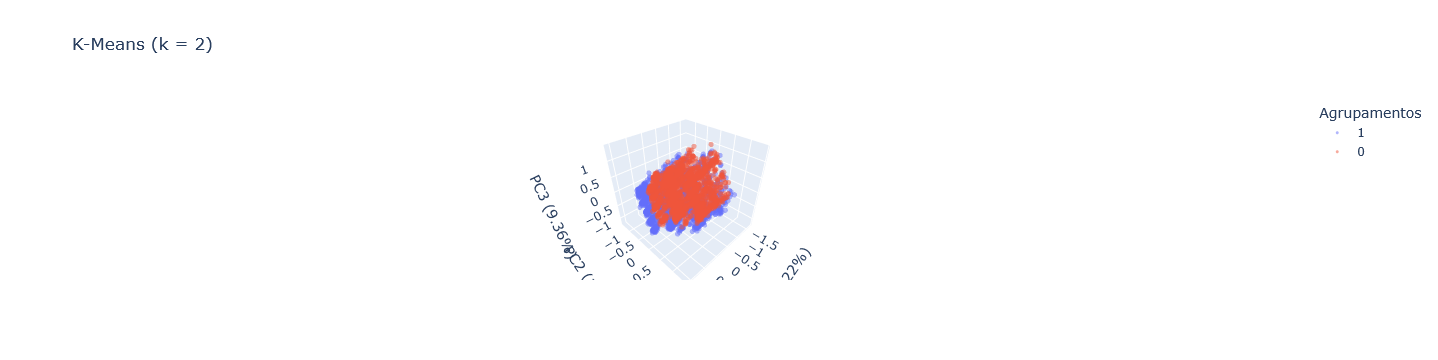

In [15]:
# testes de k-means com diferentes valors de k
plotar_kmeans(k=2)

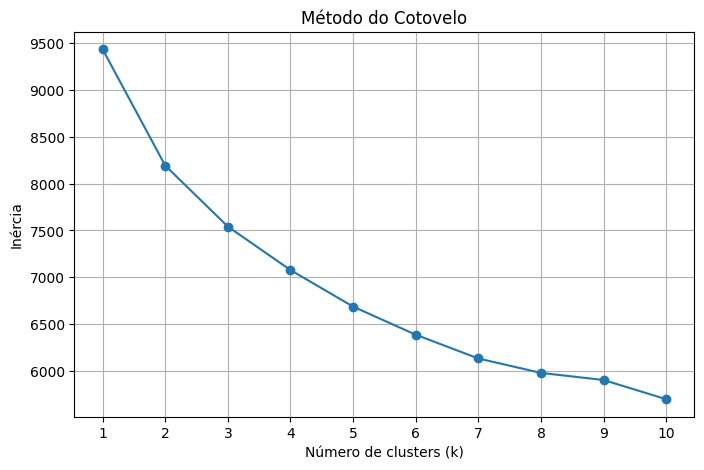

In [10]:
# Método do cotovelo
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )

    kmeans.fit(scaled_students_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.xticks(K)
plt.grid(True)
plt.savefig('metodo_cotovelo.png', dpi=300, bbox_inches='tight')
plt.show()

k = 2: 0.1406
k = 3: 0.1266
k = 4: 0.1175
k = 5: 0.1308
k = 6: 0.1322
k = 7: 0.1296
k = 8: 0.1035
k = 9: 0.0982
k = 10: 0.1101


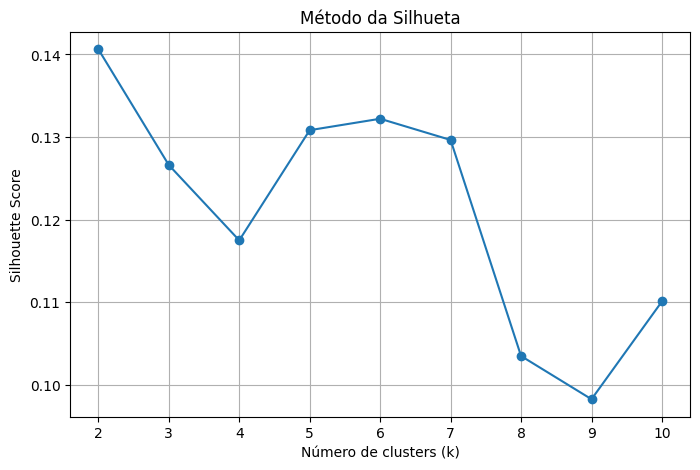

In [9]:
silhouette_scores = []
K = range(2, 11)  

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )

    labels = kmeans.fit_predict(scaled_students_df)
    score = silhouette_score(scaled_students_df, labels)
    silhouette_scores.append(score)

    print(f"k = {k}: {score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método da Silhueta')
plt.xticks(K)
plt.grid(True)
plt.savefig('metodo_silhueta.png', dpi=300, bbox_inches='tight')
plt.show()

n_components = 2: 0.1406
n_components = 3: 0.1266
n_components = 4: 0.1136
n_components = 5: 0.1256
n_components = 6: 0.1201
n_components = 7: 0.1019
n_components = 8: 0.0885
n_components = 9: 0.0877
n_components = 10: 0.1043


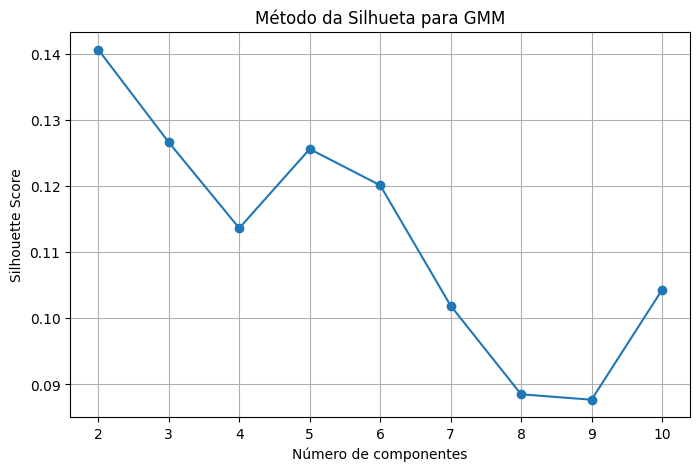

In [17]:
# Método da Silhueta para GMM
silhouette_scores = []
N = range(2, 11)

for n in N:
    gmm = GaussianMixture(
        n_components=n,
        random_state=42,
        n_init=1
    )

    labels = gmm.fit_predict(scaled_students_df)

    score = silhouette_score(
        scaled_students_df,
        labels
    )

    silhouette_scores.append(score)

    print(f"n_components = {n}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(N, silhouette_scores, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Silhouette Score')
plt.title('Método da Silhueta para GMM')
plt.xticks(N)
plt.grid(True)

plt.savefig(
    'metodo_silhueta_gmm.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

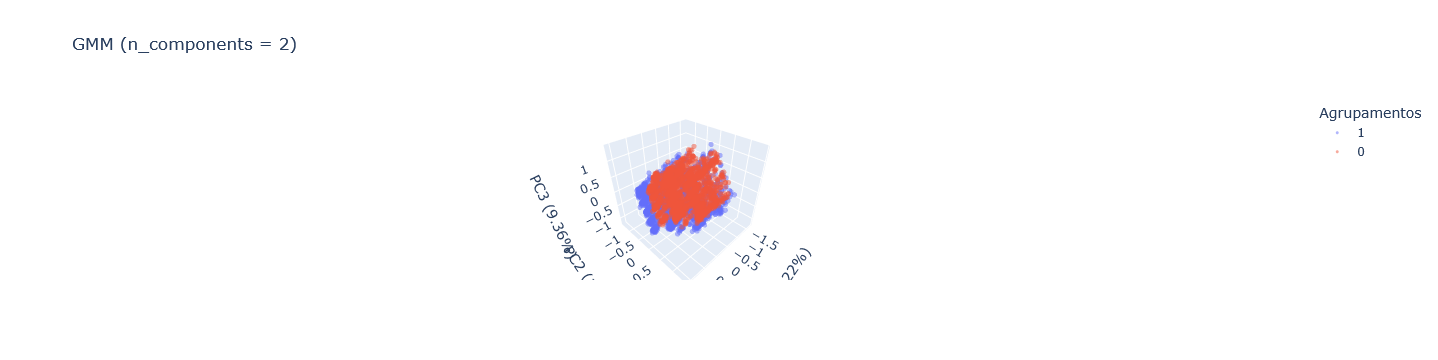

In [22]:
# testes de gmm com diferentes valors de n
plotar_gmm(n=2)